In [6]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Configuration for your overnight run ---
# Matches the loops in your experiment script
flux_list = [0e-3, 20e-3, 40e-3, 60e-3, 80e-3, 90e-3, 100e-3, 110e-3, 120e-3]
qubit_amps = [0.1, 0.3, 0.6, 0.8, 1.2]

# Define the two days of data
batches = [
    {"folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-26/", "time_start": (22, 25, 56), "time_end": (23, 59, 59)},
    {"folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-27/", "time_start": (0, 0, 0), "time_end": (2, 46, 36)}
]

def get_folders(batch):
    folder = batch["folder"]
    if not os.path.exists(folder): return []
    
    # Get all QubitSpec directories
    dirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d)) and "QubitSpec.hdf5" in d]
    
    def extract_full_t(dname):
        # Format is HH-MM-SS_QubitSpec
        parts = dname.split("_")[0].split("-")
        return (int(parts[0]), int(parts[1]), int(parts[2]))

    # Filter by the full HH-MM-SS timestamp
    filtered = [os.path.join(folder, d) for d in dirs 
                if batch["time_end"] >= extract_full_t(d) >= batch["time_start"]]
    filtered.sort() # Critical: this ensures they match your loop order
    return filtered

# 1. Collect all folders across both days
all_spec_folders = []
for b in batches:
    all_spec_folders.extend(get_folders(b))

print(f"Total folders found: {len(all_spec_folders)}")

# # 2. Map Folders to Amps and Flux
# # Since your loop was: for amp in amps: for flux in fluxes: ...
# # Each 'amp' block has len(flux_list) folders.
# mapped_data = [] 
# folder_idx = 0

# for a_idx, amp in enumerate(qubit_amps):
#     for f_idx, flux in enumerate(flux_list):
#         if folder_idx < len(all_spec_folders):
#             path = all_spec_folders[folder_idx]
#             mapped_data.append({
#                 "amp": amp,
#                 "flux": flux * 1e3, # convert to mA
#                 "path": path
#             })
#             folder_idx += 1

# # 3. Choose an Amplitude to Plot (e.g., 0.3)
# target_amp = 0.3
# plot_data = [d for d in mapped_data if d["amp"] == target_amp]

# final_flux_axis = []
# final_mag_matrix = []
# freq_axis = None

# for entry in plot_data:
#     # Find the .hdf5 file inside the folder
#     h5_files = [f for f in os.listdir(entry["path"]) if f.endswith(".hdf5")]
#     if not h5_files: continue
    
#     try:
#         with h5py.File(os.path.join(entry["path"], h5_files[0]), "r") as f:
#             if freq_axis is None:
#                 # Reconstruct absolute frequency: LO + IF
#                 # Adjust keys if your HDF5 uses different names
#                 lo = f.attrs.get("qubit_lo", 5e9) 
#                 freq_axis = (lo + f["qubit_frequency"][()]) / 1e9 # GHz
            
#             mag = np.mean(f["Magnitude"][()], axis=0)
#             final_mag_matrix.append(mag)
#             final_flux_axis.append(entry["flux"])
#     except Exception as e:
#         print(f"Error reading {entry['path']}: {e}")

# # 4. Heatmap
# if final_mag_matrix:
#     plt.figure(figsize=(10, 6))
#     plt.pcolormesh(freq_axis, final_flux_axis, final_mag_matrix, shading='auto', cmap='viridis')
#     plt.colorbar(label='Magnitude')
#     plt.xlabel('Qubit Frequency (GHz)')
#     plt.ylabel('Flux (mA)')
#     plt.title(f'Qubit Spectroscopy at Amp={target_amp}')
#     plt.show()

Total folders found: 0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- 1. Your Experiment Loop Parameters ---
flux_list = [0e-3, 20e-3, 40e-3, 60e-3, 80e-3, 90e-3, 100e-3, 110e-3, 120e-3]
qubit_amps = [0.1, 0.3, 0.6, 0.8, 1.2]
base_dirs = [
    r"C:\Users\qcrew\Documents\eunice\data\2026-02-26",
    r"C:\Users\qcrew\Documents\eunice\data\2026-02-27"
]

# --- 2. Find and Sort All Experiment Folders ---
all_spec_folders = []
for root_dir in base_dirs:
    if not os.path.exists(root_dir): continue
    # Find folders named like "HH-MM-SS_QubitSpec"
    dirs = [os.path.join(root_dir, d) for d in os.listdir(root_dir) 
            if os.path.isdir(os.path.join(root_dir, d)) and "QubitSpec" in d]
    all_spec_folders.extend(dirs)

# Sort strictly by folder name (timestamp) to match the loop order
all_spec_folders.sort()

print(f"Found {len(all_spec_folders)} folders. Expected {len(qubit_amps) * len(flux_list)}.")

# --- 3. Map Parameters to Folders ---
# Since loops were: for amp in amps: for flux in fluxes:
folder_map = []
idx = 0
for amp in qubit_amps:
    for flux in flux_list:
        if idx < len(all_spec_folders):
            folder_map.append({"amp": amp, "flux": flux * 1e3, "path": all_spec_folders[idx]})
            idx += 1

# --- 4. Process and Plot (Select Amplitude) ---
target_amp = 0.3 # Change this to see different power levels
plot_data = [d for d in folder_map if d["amp"] == target_amp]

freq_axis = None
flux_axis = []
z_matrix = []

for entry in plot_data:
    # Look for any .hdf5 file INSIDE the folder
    h5_files = [f for f in os.listdir(entry["path"]) if f.endswith(".hdf5")]
    if not h5_files: continue
    
    file_path = os.path.join(entry["path"], h5_files[0])
    try:
        with h5py.File(file_path, "r") as f:
            # Reconstruct Frequency: LO + IF
            # Adjust 'qubit_lo' and 'qubit_frequency' to match your actual HDF5 keys
            lo = f.attrs.get("qubit_lo", 5e9) 
            if_freqs = f["qubit_frequency"][()]
            
            if freq_axis is None:
                freq_axis = (lo + if_freqs) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0) # Avg over repetitions
            z_matrix.append(mag)
            flux_axis.append(entry["flux"])
    except Exception as e:
        print(f"Error in {entry['path']}: {e}")

# --- 5. Generate Heatmap ---
if z_matrix:
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(freq_axis, flux_axis, z_matrix, shading='auto', cmap='magma')
    plt.title(f"Qubit Tunability (Amp: {target_amp})")
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Flux Bias (mA)")
    plt.colorbar(label="Magnitude (V)")
    plt.show()

Found 0 folders. Expected 45.


In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# Your specific directory
data_dir = r'C:\Users\qcrew\Documents\eunice\data\2026-02-21'
file_name = '12-51-32_CavitySWAP2D.hdf5'
full_path = os.path.join(data_dir, file_name)


with h5py.File(full_path, 'r') as f:
    amp = f['snail_ampx'][:]      # Shape: (11,)
    length = f['length_snail'][:] # Shape: (63,)
    raw_mag = f['Magnitude'][:]   # Shape: (5000, 11, 63)
    
    # Average over the 5000 time-trace points (axis 0)
    mag = np.mean(raw_mag, axis=0) # New Shape: (11, 63)

# Now check for transposition
# pcolormesh expects C to be (len(Y), len(X)) or for X/Y to match dimensions
if mag.shape == (len(amp), len(length)):
    mag = mag.T # Transpose to (63, 11) to match Y(63) and X(11)

plt.figure(figsize=(9, 6))
plt.pcolormesh(amp, length, mag, shading='auto', cmap='RdBu_r')
plt.colorbar(label='Mean Magnitude')
plt.xlabel('SNAIL Amplitude (snail_ampx)')
plt.ylabel('SNAIL Pulse Length (length_snail)')
plt.show()

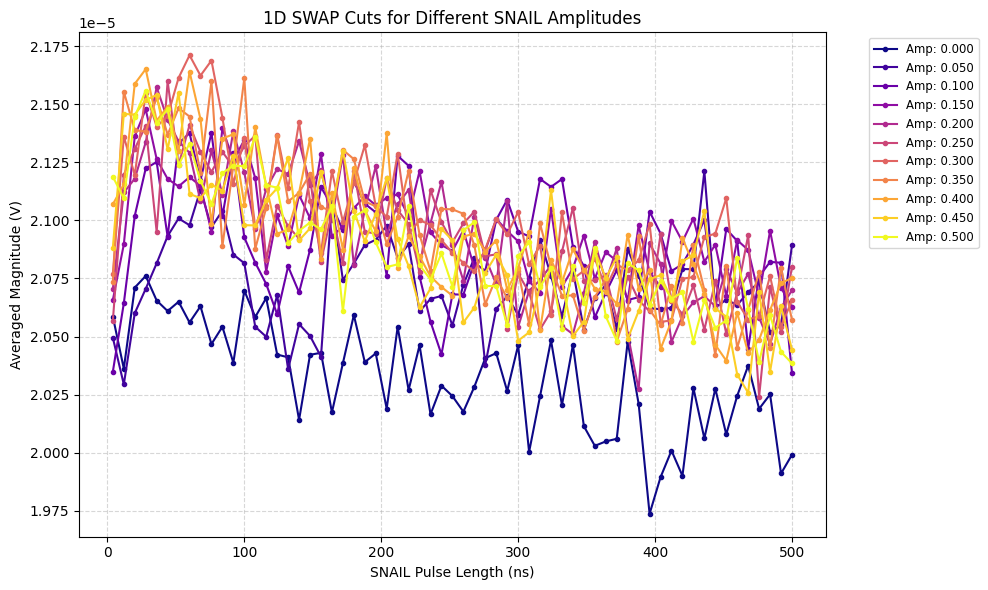

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# Path setup
data_dir = r'C:\Users\qcrew\Documents\eunice\data\2026-02-21'
file_name = '12-51-32_CavitySWAP2D.hdf5'
full_path = os.path.join(data_dir, file_name)

with h5py.File(full_path, 'r') as f:
    amp = f['snail_ampx'][:]
    length = f['length_snail'][:]
    # Average the ADC dimension immediately
    mag_2d = np.mean(f['Magnitude'][:], axis=0) # Shape (11, 63)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(amp)))

# Loop through each amplitude and plot the 1D cut
for i, a_val in enumerate(amp):
    # mag_2d[i, :] gives the 63 length points for the i-th amplitude
    plt.plot(length, mag_2d[i, :], label=f'Amp: {a_val:.3f}', color=colors[i], marker='o', markersize=3)

plt.xlabel('SNAIL Pulse Length (ns)')
plt.ylabel('Averaged Magnitude (V)')
plt.title('1D SWAP Cuts for Different SNAIL Amplitudes')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Target: 0.1, Found: 0.10000000149011612 at index 2


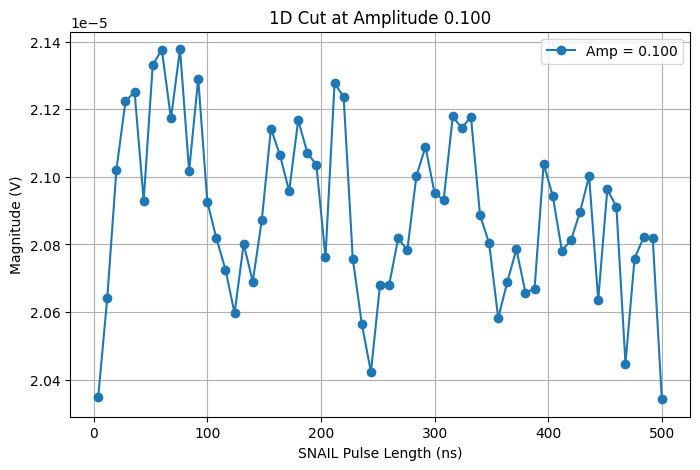

In [10]:
target_amp = 0.1 # The amplitude you are looking for

# Find the index of the amplitude closest to your target
idx = np.argmin(np.abs(amp - target_amp))
actual_amp = amp[idx]

print(f"Target: {target_amp}, Found: {actual_amp} at index {idx}")

plt.figure(figsize=(8, 5))
# Access the 2D matrix at the specific amplitude index
plt.plot(length, mag_2d[idx, :], 'o-', label=f'Amp = {actual_amp:.3f}')

plt.xlabel('SNAIL Pulse Length (ns)')
plt.ylabel('Magnitude (V)')
plt.title(f'1D Cut at Amplitude {actual_amp:.3f}')
plt.legend()
plt.grid(True)
plt.show()